In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import load_iris

### Skaliranje

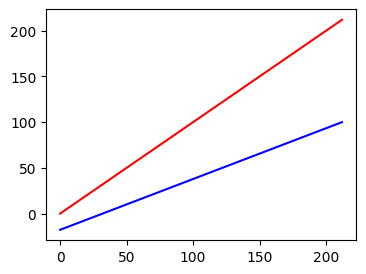

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
temperature_f = np.linspace(0, 212, 100)
temperature_c = (5/9) * (temperature_f - 32)
plt.plot(temperature_f, temperature_f, 'r',
         temperature_f, temperature_c, 'b')

### StandardScaler

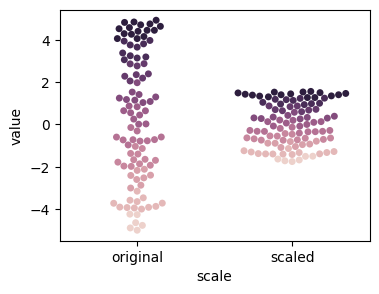

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
original = np.random.uniform(-5, 5, 100)
scaled = StandardScaler().fit_transform(original.reshape(-1, 1))[:,0]
bins = np.floor(original).astype(np.uint8) + 5

df = pd.DataFrame({'original':original,
                   'scaled':scaled,
                   'hue':bins})
df = pd.melt(df, id_vars='hue', var_name='scale')

sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()

### MinMax Scaler

/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 48.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 24.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 7.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/davorin-ai/workspace/education-ai/ai-centar-lipik/.venv/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 56.7% of the points cannot be placed; you may wa

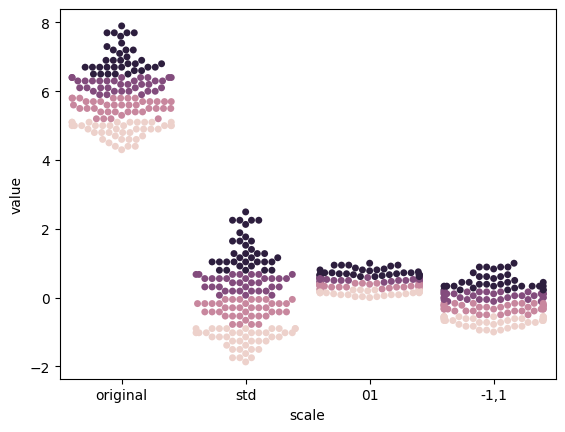

In [17]:
iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
bins  = pd.cut(iris_df['sepal length (cm)'], np.percentile(iris_df['sepal length (cm)'], [25, 50, 75, 100])).cat.codes

df = pd.DataFrame({
    'original':iris_df['sepal length (cm)'],
    'hue':bins
})
scalers = [('std', StandardScaler()),
           ('01', MinMaxScaler()),
           ('-1,1', MinMaxScaler((-1, 1)))]
for name, scaler in scalers:
    df[name] = scaler.fit_transform(df[['original']]).reshape(-1)

df = pd.melt(df, id_vars='hue', var_name='scale')
sns.swarmplot(x='scale', y='value', hue='hue', data=df).legend_.remove()